# Serial Repetition Lag-CRP

> Analyze repetition contiguity conditioned on correctly ordered recall.

The serial repetition CRP conditions on correctly ordered output up to the point of analysis. It tabulates repetition-index CRPs only for transitions where the recall sequence matches study order, stopping once an out-of-order response occurs. This isolates temporal contiguity effects in participants who are maintaining serial order.

## Workflow

In [1]:
import os

import jax.numpy as jnp
import matplotlib.pyplot as plt

from jaxcmr.analyses.serialrepcrp import plot_rep_crp, subject_serial_rep_crp, test_serial_rep_crp_vs_control
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data, save_figure
from jaxcmr.repetition import make_control_dataset

In [2]:
allow_repeated_recalls = True
filter_repeated_recalls = False
data_path = "data/RepeatedRecallsKahanaJacobs2000.h5"
figure_dir = "results/figures"
figure_str = ""
ylim = [0, .9]
base_data_name = "KahanaJacobs2000"
# trial_query = "data['condition'] == 2"
# mixed_trial_query = "jnp.logical_and(data['condition'] == 2, data['lag'] != 4)"
# control_trial_query = "jnp.logical_and(data['condition'] == 2, data['lag'] == 4)"
trial_query = "jnp.logical_and(data['recall_attempt'] == 1, data['recall_total'] > 0)"

mixed_trial_query = "jnp.logical_and(jnp.logical_and(data['recall_attempt'] == 1, data['recall_total'] > 0), data['repetitions'] == 1)"
control_trial_query = "jnp.logical_and(jnp.logical_and(data['recall_attempt'] == 1, data['recall_total'] > 0), data['repetitions'] == 0)"
control_shuffles = 10
control_seed = 0
min_lag = 2
max_lag = 3
size = 2


In [3]:
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)
data_path = os.path.join(project_root, data_path)
data = load_data(data_path)
trial_mask = generate_trial_mask(data, trial_query)
mixed_mask = generate_trial_mask(data, mixed_trial_query) & trial_mask

control_dataset = make_control_dataset(
    data,
    mixed_query=mixed_trial_query,
    control_query=control_trial_query,
    n_shuffles=control_shuffles,
    remove_repeats=filter_repeated_recalls,
    seed=control_seed,
)
control_mask = jnp.ones((control_dataset["recalls"].shape[0],), dtype=bool)


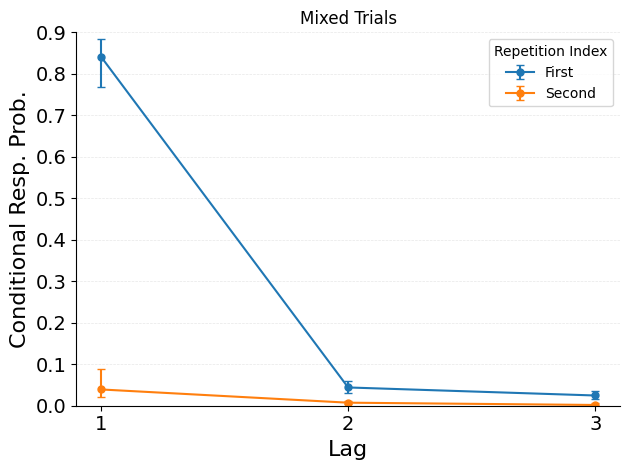

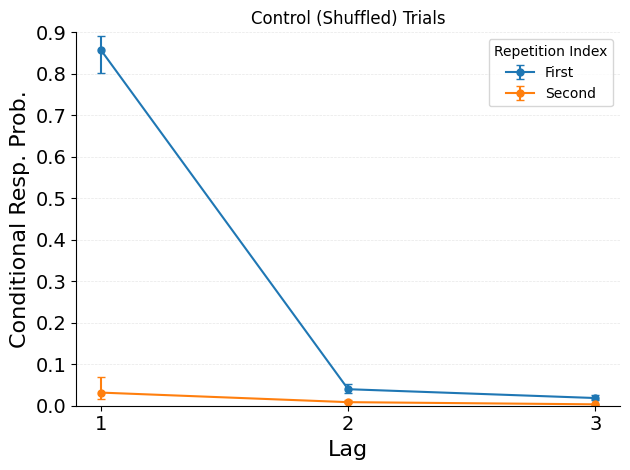

In [4]:
plot_rep_crp(
    datasets=data,
    trial_masks=mixed_mask,
    max_lag=max_lag,
    min_lag=min_lag,
    size=size,
    labels=("First", "Second"),
    contrast_name="Repetition Index",
)
plt.title("Mixed Trials")
if ylim is not None:
    for ax in plt.gcf().axes:
        ax.set_ylim(ylim)
save_figure(figure_dir, figure_str, suffix="mixed")

plot_rep_crp(
    datasets=control_dataset,
    trial_masks=control_mask,
    max_lag=max_lag,
    min_lag=min_lag,
    size=size,
    labels=("First", "Second"),
    contrast_name="Repetition Index",
)
plt.title("Control (Shuffled) Trials")
if ylim is not None:
    for ax in plt.gcf().axes:
        ax.set_ylim(ylim)
save_figure(figure_dir, figure_str, suffix="control")


In [5]:
observed_crp = subject_serial_rep_crp(data, mixed_mask, min_lag, max_lag, size)
control_crp = subject_serial_rep_crp(control_dataset, control_mask, min_lag, max_lag, size)

results = test_serial_rep_crp_vs_control(observed_crp, control_crp, max_lag)
for label, result in results.items():
    print()
    print("=" * 60)
    print(f"Statistical Tests: {label}")
    print("=" * 60)
    print(result)



Statistical Tests: First Presentation
  Lag |   t-stat    t p-val |   W-stat    W p-val |  Mean Diff
------+----------------------+----------------------+------------
    1 |   -1.648     0.1167 |     54.0     0.1042 |    -0.0158
    2 |    0.999     0.3309 |     68.0     0.2935 |     0.0042
    3 |    1.192     0.2486 |     66.0     0.2579 |     0.0061

Statistical Tests: Second Presentation
  Lag |   t-stat    t p-val |   W-stat    W p-val |  Mean Diff
------+----------------------+----------------------+------------
    1 |    1.814     0.0864 |     54.0     0.1042 |     0.0076
    2 |   -0.511     0.6154 |     81.0     0.5949 |    -0.0013
    3 |   -1.390     0.1815 |     25.0     0.0843 |    -0.0015


## Interpretation

Plots show repetition CRP curves computed only from correctly ordered recall prefixes. Key patterns:

- **Stronger contiguity under order**: if serial-order maintenance amplifies temporal contiguity, curves will be steeper than unconditioned repetition CRP.
- **Observed vs. control**: differences isolate repetition-specific effects in order-maintaining recall.
- **First vs. second presentation**: reveals which occurrence drives transitions when participants recall in order.

## API Details

### Notebook parameters

This template uses the same parameter set as the repetition Lag-CRP template. See that template's API Details for parameter descriptions. Additional parameters:

- `allow_repeated_recalls` — whether the analysis permits repeated recalls.
- `filter_repeated_recalls` — whether to filter out repeated recall events.